# LGR5 Marker-Domain Analysis

Train one or more GIN models and analyze predicted curvature profiles around connected LGR5-positive domains.

In [1]:
import copy
import inspect
import json
import math
import pickle
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


In [2]:
# Data and target settings
DATASET_NAME = "mean_curvature_smooth"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_ANALYSIS = 0
USE_GLOBAL_FEATURES = True

# Filtering and preprocessing settings
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split settings
VAL_FRAC = 0.2
SPLIT_SEED = None
FORCED_VAL_KEYS = set()

# Model settings
DEPTHS = [2, 4]
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Marker-domain analysis settings
DOMAIN_MARKER = "LGR5"
MARKER_THRESHOLD = 0.5
MAX_OUTSIDE_DISTANCE = 4
MAX_INSIDE_DISTANCE = None
SIZE_BINS = list(range(1, 9))
OVERFLOW_SIZE_BIN = True
OVERFLOW_LABEL = "8+"
RUN_SHRINK = True
SHRINK_TARGET_SIZES = None
INCLUDE_ALL_INTERMEDIATE_SHRINK_SIZES = False
MAX_COMPONENTS_FOR_SHRINK = 200
DOMAIN_BATCH_SIZE = 64

## Load And Filter Graphs

In [3]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
)

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers:", marker_names)

print_graph_and_metadata_fields(graphs)

Loaded 1134 graphs; skipped 0.
Loaded 1134 organoids.
Raw y shape: (265, 2)
Attached metadata to 1134/1134 graphs.
Selected y shape: (265,)
Loaded 7 markers: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [4]:
from src.data.metadata import fill_missing_metadata_for_group
from src.data.filters import (
    filter_graphs_by_marker_diversity,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
    dataset=MISSING_COMPLEXITY_GROUP["dataset"],
    timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
)

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

graphs = graphs + g_spherical
print(f"After filtering and spherical rescue: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None

filter_graphs_by_sphericity(max_sphericity=0.92): kept 819 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                244    342    0.713
20250929         day4p5               89    104    0.856
20250929         day4p5-more         290    411    0.706
20251201         day4p5              196    277    0.708
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 93 / 315 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                 37     98    0.378
20250929         day4p5                9     15    0.600
20250929         day4p5-more          27    121    0.223
20251201         day4p5               20     81    0.247
filter_graphs_by_numeric_metadata(key='complexity', min_value=2.0, max_value=None): kept 712 / 819 graphs

dataset          timepoint          kept  total

In [5]:
from src.data.metadata import add_log_metadata_features, promote_metadata_to_graph_tensors

field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")

Promoted metadata fields to graph tensor attributes.


In [6]:
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.metadata import infer_global_dim, snapshot_graph_metadata, strip_graph_metadata
from src.data.target_transforms import AsinhStandardizeTransform, standardize_graph_global_features

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    force_val_keys=FORCED_VAL_KEYS,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

val_meta_lookup = snapshot_graph_metadata(g_val)

g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

target_transform = AsinhStandardizeTransform(robust=True).fit(g_train)
target_transform.transform_graphs(g_train)
target_transform.transform_graphs(g_val)

center_global, scale_global = None, None
if USE_GLOBAL_FEATURES:
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

global_dim = infer_global_dim(g_train)
print("global_dim =", global_dim)
print("target_transform =", target_transform.name)

Split -> train: 644 | val: 161
global_dim = 4
target_transform = asinh_standardize


## Train GIN Models

In [7]:
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

aux_losses = [
    WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params=EDGE_LOSS_PARAMS,
    ),
]

cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=aux_losses,
)

device = cfg.device if "cfg" in globals() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

device = cuda


In [8]:
trained_models = {}
training_logs = {}

for depth in DEPTHS:
    print("\n" + "=" * 80)
    print(f"Training GINCurvature depth={depth}")

    model = GINCurvature(
        n_markers=int(g_train[0].x.size(1)),
        global_dim=infer_global_dim(g_train),
        hidden_dim=HIDDEN_DIM,
        num_layers=int(depth),
        dropout=DROPOUT,
        residual=RESIDUAL,
        norm=NORM,
    )

    model, metrics, history = train(model, g_train, g_val, cfg)
    trained_models[int(depth)] = model
    training_logs[int(depth)] = {
        "metrics": metrics,
        "history": history,
    }

print("Finished training depths:", list(trained_models))


Training GINCurvature depth=2
epoch 001 | train loss 0.5716 mae 0.7789 | val loss 0.4844 mae 0.7346
epoch 002 | train loss 0.4884 mae 0.7322 | val loss 0.4613 mae 0.7170
epoch 003 | train loss 0.4630 mae 0.7163 | val loss 0.4660 mae 0.7211
epoch 004 | train loss 0.4572 mae 0.7175 | val loss 0.4483 mae 0.6981
epoch 005 | train loss 0.4486 mae 0.7054 | val loss 0.4553 mae 0.7109
epoch 006 | train loss 0.4342 mae 0.6995 | val loss 0.4469 mae 0.7020
epoch 007 | train loss 0.4278 mae 0.6993 | val loss 0.4362 mae 0.6911
epoch 008 | train loss 0.4244 mae 0.6920 | val loss 0.4526 mae 0.7071
epoch 009 | train loss 0.4176 mae 0.6923 | val loss 0.4339 mae 0.6858
epoch 010 | train loss 0.4113 mae 0.6874 | val loss 0.4411 mae 0.6970
epoch 011 | train loss 0.4081 mae 0.6857 | val loss 0.4570 mae 0.7179
epoch 012 | train loss 0.4072 mae 0.6869 | val loss 0.4253 mae 0.6830
epoch 013 | train loss 0.4067 mae 0.6845 | val loss 0.4299 mae 0.6916
epoch 014 | train loss 0.4051 mae 0.6818 | val loss 0.4227 

## LGR5 Domain Analysis

In [9]:
from src.analysis.marker_domain import (
    marker_index_from_name,
    run_marker_domain_profile_analysis,
    size_bin_order_from_spec,
    plot_domain_profiles,
    plot_observed_vs_shrink_profiles,
    plot_shrink_delta_profiles,
)

# Resolve robustly in case the loaded marker names differ in capitalization.
try:
    domain_marker_index = marker_index_from_name(DOMAIN_MARKER, marker_names)
    domain_marker_name = marker_names[domain_marker_index]
except ValueError:
    lower_lookup = {name.lower(): i for i, name in enumerate(marker_names)}
    key = str(DOMAIN_MARKER).lower()
    if key not in lower_lookup:
        raise
    domain_marker_index = lower_lookup[key]
    domain_marker_name = marker_names[domain_marker_index]

print(f"Analyzing marker {domain_marker_name!r} at feature column {domain_marker_index}.")

n_positive_by_graph = [int((g.x[:, domain_marker_index] > MARKER_THRESHOLD).sum().item()) for g in g_val]
print("Validation graphs with positive cells:", sum(n > 0 for n in n_positive_by_graph), "/", len(g_val))
print("Total positive validation cells:", sum(n_positive_by_graph))

Analyzing marker 'LGR5' at feature column 4.
Validation graphs with positive cells: 152 / 161
Total positive validation cells: 16419


In [10]:
domain_results_by_depth = {}

for depth, model in trained_models.items():
    print("\n" + "=" * 80)
    print(f"Marker-domain analysis for {domain_marker_name} | depth={depth}")

    result = run_marker_domain_profile_analysis(
        graphs=g_val,
        model=model,
        marker=domain_marker_index,
        marker_names=marker_names,
        marker_threshold=MARKER_THRESHOLD,
        max_outside_distance=MAX_OUTSIDE_DISTANCE,
        max_inside_distance=MAX_INSIDE_DISTANCE,
        size_bins=SIZE_BINS,
        overflow_size_bin=OVERFLOW_SIZE_BIN,
        overflow_label=OVERFLOW_LABEL,
        run_shrink=RUN_SHRINK,
        shrink_target_sizes=SHRINK_TARGET_SIZES,
        include_all_intermediate_shrink_sizes=INCLUDE_ALL_INTERMEDIATE_SHRINK_SIZES,
        max_components_for_shrink=MAX_COMPONENTS_FOR_SHRINK,
        device=device,
        batch_size=DOMAIN_BATCH_SIZE,
        target_index=TARGET_INDEX_FOR_ANALYSIS,
    )
    domain_results_by_depth[int(depth)] = result

    observed_df = result["observed_df"]
    shrink_df = result.get("shrink_df", pd.DataFrame())
    print("observed rows:", len(observed_df), "components:", len(result["components"]))
    print("shrink rows:", len(shrink_df))


Marker-domain analysis for LGR5 | depth=2
observed rows: 66373 components: 516
shrink rows: 53077

Marker-domain analysis for LGR5 | depth=4
observed rows: 66373 components: 516
shrink rows: 53077


In [11]:
component_rows = []
for depth, result in domain_results_by_depth.items():
    for comp in result["components"]:
        row = {"depth": depth, "graph_index": comp.graph_index, "component_id": comp.component_id}
        row.update(comp.stats)
        component_rows.append(row)

component_df = pd.DataFrame(component_rows)
if component_df.empty:
    print("No LGR5-positive components found.")
else:
    display(component_df.groupby("depth")["cluster_size"].describe())
    display(component_df.head())

,count,mean,std,min,25%,50%,75%,max
depth,,,,,,,,
2,516.0,31.819767,68.438481,1.0,1.0,2.0,27.0,516.0
4,516.0,31.819767,68.438481,1.0,1.0,2.0,27.0,516.0


,depth,graph_index,component_id,cluster_size,internal_edges,edge_density,mean_internal_degree,boundary_edges,n_boundary_nodes,boundary_fraction,mean_boundary_exposure,edge_surplus_ratio
0,2,0,0,1,0,NaN,0.000000,5,1,1.000000,5.000000,NaN
1,2,1,0,29,73,0.179803,5.034483,22,11,0.379310,0.758621,2.607143
2,2,1,1,22,45,0.194805,4.090909,41,17,0.772727,1.863636,2.142857
3,2,1,2,2,1,1.000000,1.000000,9,2,1.000000,4.500000,1.000000
4,2,1,3,1,0,NaN,0.000000,5,1,1.000000,5.000000,NaN


## Plot Results

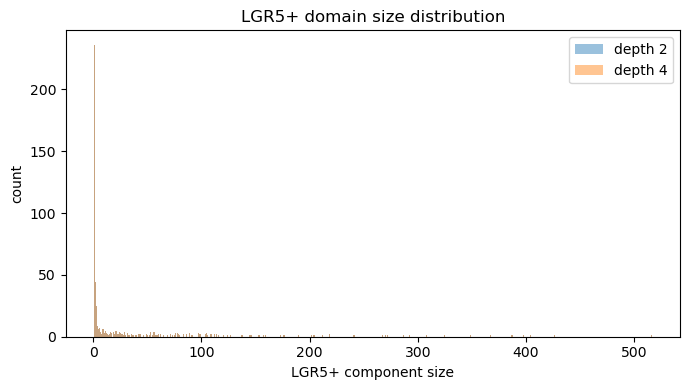

In [12]:
if not component_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    bins = np.arange(1, component_df["cluster_size"].max() + 2) - 0.5
    for depth, sub in component_df.groupby("depth"):
        ax.hist(sub["cluster_size"], bins=bins, alpha=0.45, label=f"depth {depth}")
    ax.set_xlabel(f"{domain_marker_name}+ component size")
    ax.set_ylabel("count")
    ax.set_title(f"{domain_marker_name}+ domain size distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

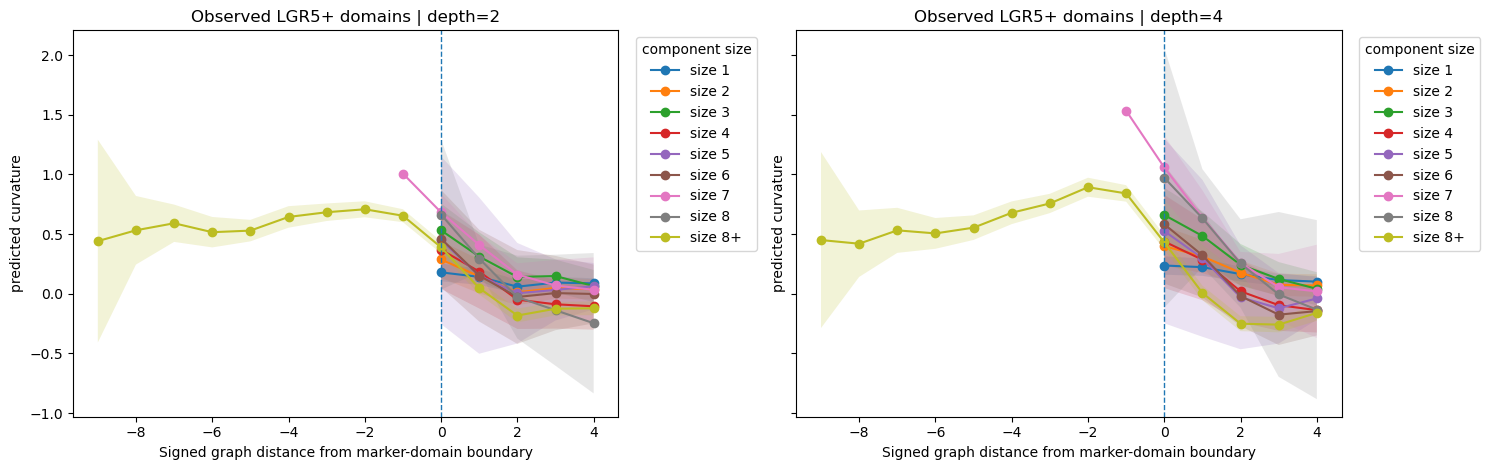

In [13]:
n_depths = len(domain_results_by_depth)
fig, axes = plt.subplots(1, n_depths, figsize=(7.5 * n_depths, 4.8), squeeze=False, sharey=True)
axes = axes.ravel()

for ax, (depth, result) in zip(axes, domain_results_by_depth.items()):
    observed_df = result["observed_df"]
    if observed_df.empty:
        ax.set_title(f"depth={depth}: no domains")
        ax.axis("off")
        continue
    plot_domain_profiles(
        observed_df,
        value_col="mu",
        condition="observed",
        size_bins=SIZE_BINS,
        overflow_size_bin=OVERFLOW_SIZE_BIN,
        overflow_label=OVERFLOW_LABEL,
        ax=ax,
        title=f"Observed {domain_marker_name}+ domains | depth={depth}",
        ylabel="predicted curvature",
    )

plt.tight_layout()
plt.show()

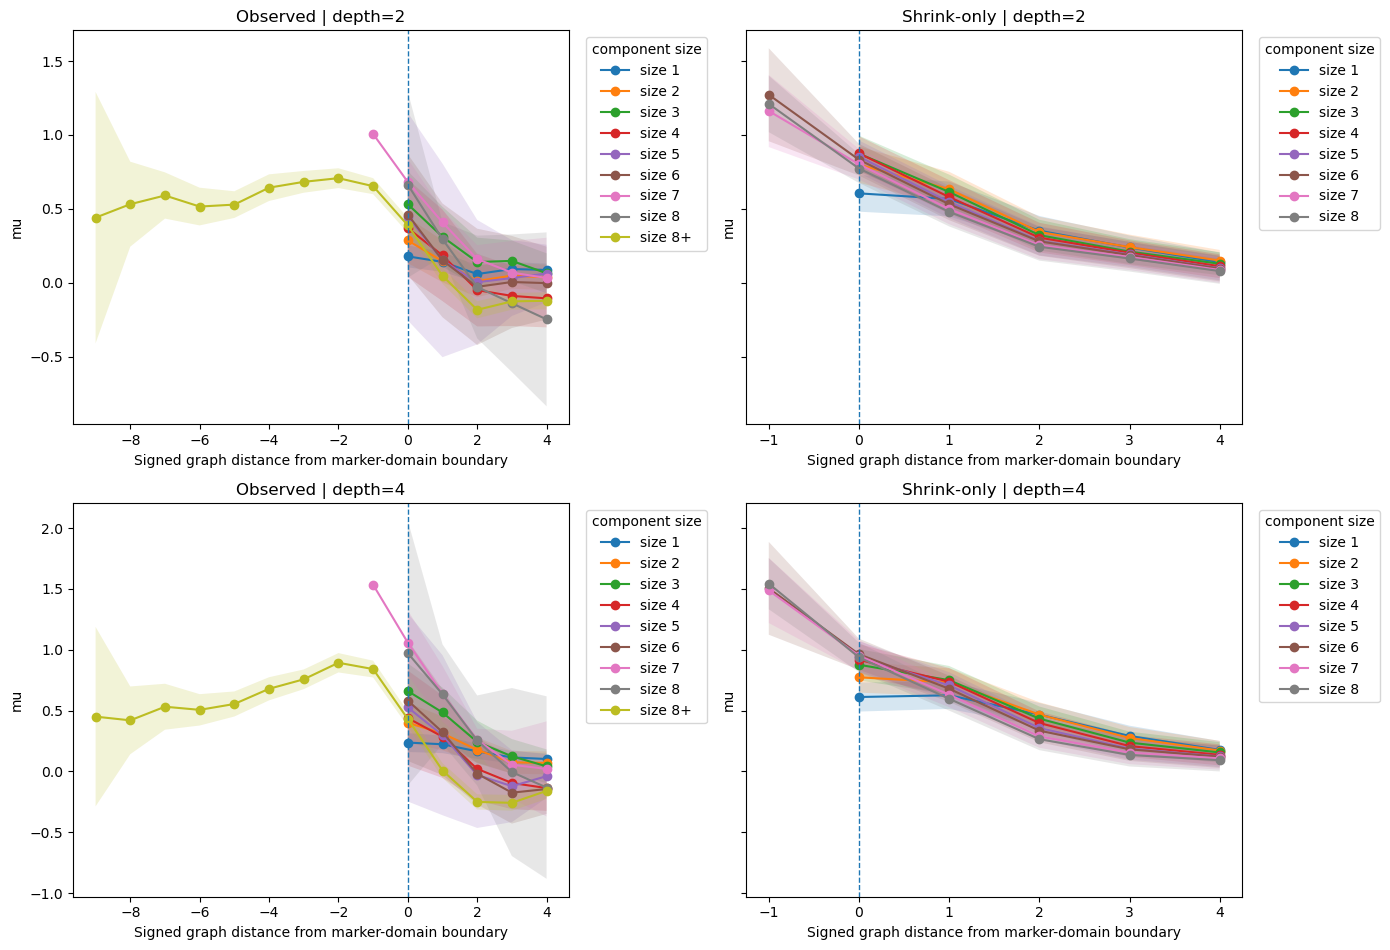

In [14]:
if RUN_SHRINK:
    n_depths = len(domain_results_by_depth)
    fig, axes = plt.subplots(n_depths, 2, figsize=(14, 4.8 * n_depths), squeeze=False, sharey="row")

    for row, (depth, result) in enumerate(domain_results_by_depth.items()):
        observed_df = result["observed_df"]
        shrink_df = result.get("shrink_df", pd.DataFrame())
        if observed_df.empty or shrink_df.empty:
            axes[row, 0].set_title(f"depth={depth}: insufficient shrink data")
            axes[row, 0].axis("off")
            axes[row, 1].axis("off")
            continue
        plot_observed_vs_shrink_profiles(
            observed_df,
            shrink_df,
            value_col="mu",
            size_bins=SIZE_BINS,
            overflow_size_bin=OVERFLOW_SIZE_BIN,
            overflow_label=OVERFLOW_LABEL,
            axes=axes[row],
        )
        axes[row, 0].set_title(f"Observed | depth={depth}")
        axes[row, 1].set_title(f"Shrink-only | depth={depth}")

    plt.tight_layout()
    plt.show()

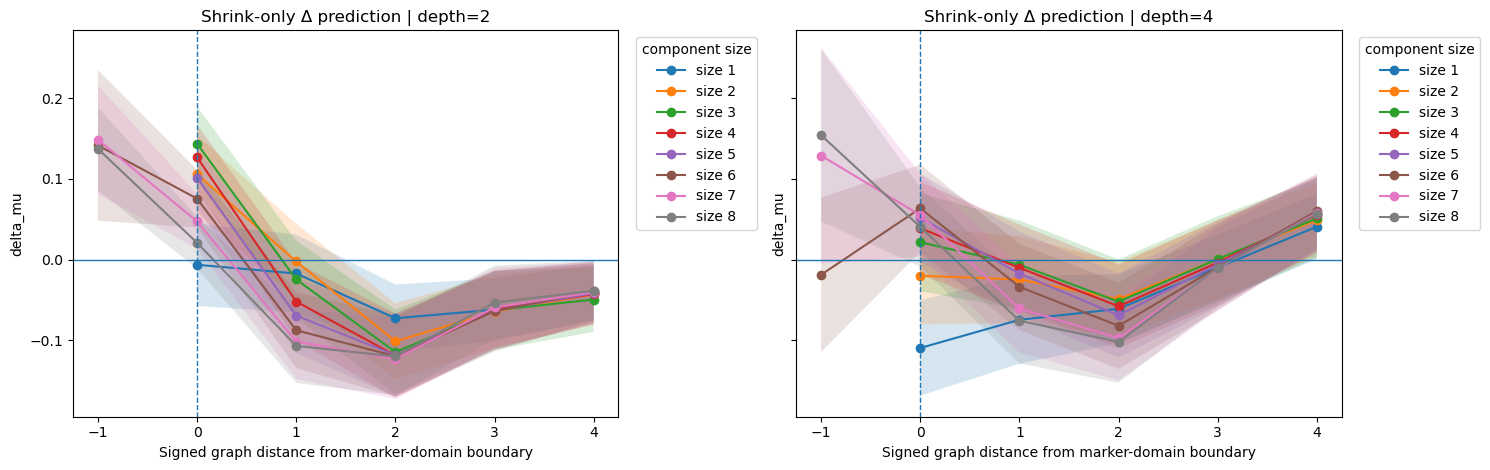

In [15]:
if RUN_SHRINK:
    n_depths = len(domain_results_by_depth)
    fig, axes = plt.subplots(1, n_depths, figsize=(7.5 * n_depths, 4.8), squeeze=False, sharey=True)
    axes = axes.ravel()

    for ax, (depth, result) in zip(axes, domain_results_by_depth.items()):
        shrink_df = result.get("shrink_df", pd.DataFrame())
        if shrink_df.empty:
            ax.set_title(f"depth={depth}: no shrink rows")
            ax.axis("off")
            continue
        plot_shrink_delta_profiles(
            shrink_df,
            value_col="delta_mu",
            size_bins=SIZE_BINS,
            overflow_size_bin=OVERFLOW_SIZE_BIN,
            overflow_label=OVERFLOW_LABEL,
            ax=ax,
            title=f"Shrink-only Δ prediction | depth={depth}",
        )

    plt.tight_layout()
    plt.show()

In [16]:
summary_rows = []
for depth, result in domain_results_by_depth.items():
    obs = result["observed_summary"].copy()
    if not obs.empty:
        obs["depth"] = depth
        obs["quantity"] = "mu"
        summary_rows.append(obs)

    shrink_delta = result.get("shrink_summary_delta_mu", pd.DataFrame()).copy()
    if not shrink_delta.empty:
        shrink_delta["depth"] = depth
        shrink_delta["quantity"] = "delta_mu"
        summary_rows.append(shrink_delta)

summary_df = pd.concat(summary_rows, ignore_index=True) if summary_rows else pd.DataFrame()
display(summary_df.head(20))

,condition,size_bin,signed_distance,mean,std,n,n_cells,n_components,sem,ci95,depth,quantity
0,observed,1,0,0.179318,0.585093,236,236,236,0.038086,0.074649,2,mu
1,observed,1,1,0.141758,0.528739,236,1289,236,0.034418,0.067459,2,mu
2,observed,1,2,0.059622,0.452256,236,2867,236,0.029439,0.057701,2,mu
3,observed,1,3,0.093746,0.368625,236,4592,236,0.023995,0.047031,2,mu
4,observed,1,4,0.087179,0.339388,236,6263,236,0.022092,0.043301,2,mu
5,observed,2,0,0.287205,0.521179,44,88,44,0.078571,0.153999,2,mu
6,observed,2,1,0.146024,0.481034,44,346,44,0.072519,0.142137,2,mu
7,observed,2,2,0.012421,0.369215,44,654,44,0.055661,0.109096,2,mu
8,observed,2,3,0.048902,0.301363,44,976,44,0.045432,0.089047,2,mu
9,observed,2,4,0.037342,0.286883,44,1264,44,0.043249,0.084768,2,mu
